# Chapter 17: Sequence-to-Sequence Architectures: Encoder-Decoders and Decoders
Character-level encoder-decoder translator


Programs from the book: [_Python for Natural Language Processing_](https://link.springer.com/book/9783031575488)

__Author__: Pierre Nugues

## Download the data

Have a look at the http://www.manythings.org/anki/ site and select a corpus with at least 10,000 pairs. You should understand the target language well. Ideally, it should be your mother tongue.
Then uncomment and run the lines below.

In [89]:
!curl -O http://www.manythings.org/anki/swe-eng.zip
!unzip swe-eng.zip
!mkdir ../datasets/tatoeba
!mv fra.txt ../datasets/tatoeba
!rm fra-eng.zip _about.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  3  814k    3 25951    0     0  48710      0  0:00:17 --:--:--  0:00:17 48871
  6  814k    6 52231    0     0  32939      0  0:00:25  0:00:01  0:00:24 32974
 12  814k   12  102k    0     0  39648      0  0:00:21  0:00:02  0:00:19 39663
 37  814k   37  307k    0     0  88149      0  0:00:09  0:00:03  0:00:06 88194
 70  814k   70  571k    0     0   127k      0  0:00:06  0:00:04  0:00:02  127k
100  814k  100  814k    0     0   147k      0  0:00:05  0:00:05 --:--:--  157k
100  814k  100  814k    0     0   147k      0  0:00:05  0:00:05 --:--:--  193k
'unzip' is not recognized as an internal or external command,
operable program or batch file.
The syntax of the command is incorrect.
'mv' is not recognized as an internal or external command,
operable program

In [90]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

## Modules

In [91]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.optim.lr_scheduler import LambdaLR

%pip install torcheval

from torcheval.metrics.functional import bleu_score

import random
import numpy as np
import math

import matplotlib.pyplot as plt
from tqdm import tqdm
import json

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\tonny\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [92]:
random.seed(1234)
np.random.seed(1234)
torch.manual_seed(1234)

In [93]:
num_samples = 20000 #230000 #100000  # Number of samples to train on.
max_len = 100  # max number of characters per sentence

In [94]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
DEVICE = torch.device(device)
DEVICE

device(type='cpu')

## Dataset

### Creating the pairs

In [95]:
#PATH = '../datasets/tatoeba/'
PATH = r'C:/Users/tonny/Downloads/swe-eng/'   # set to the working one you found above


In [96]:
data_file = PATH + 'swe.txt'

In [97]:
with open(data_file, 'r', encoding='utf-8') as f:
    lines = f.read().strip().split('\n')

In [98]:
len(lines)

25659

In [99]:
# lines = lines[:num_samples]

In [100]:
def create_pairs(lines, max_len, num_samples, shuffle=True, anki=True):
    src_seqs = [] # source seq
    tgt_seqs = [] # target seq
    if shuffle:
        random.shuffle(lines) # shufflar datan för att modellen inte bara ska minnas ordningen på träningsdatan, => träningsdatan blir bättre
    for line in lines:
        src_seq, tgt_seq, _ = line.split('\t')
        if len(src_seq) <= max_len and len(tgt_seq) <= max_len: # datan får inte vara längre än max length för att undvika att träningen blir ostabil osv, mkt minne
            src_seqs.append(src_seq)
            tgt_seqs.append(tgt_seq)
    return src_seqs[:num_samples], tgt_seqs[:num_samples]

In [101]:
tgt_seqs, src_seqs = create_pairs(lines, max_len, num_samples)

In [102]:
len(src_seqs)

20000

In [103]:
src_seqs[5]

'De röstade.'

In [104]:
tgt_seqs[5]

'They voted.'

In [105]:
max(map(len, src_seqs)), max(map(len, tgt_seqs))

(96, 97)

### Train/Validation

Percentage train/validation

In [106]:
TRAIN_PERCENTAGE = 0.8
train_val = int(TRAIN_PERCENTAGE * num_samples)
train_val

16000

We split the lists

In [107]:
train_src_seqs = src_seqs[:train_val]
train_tgt_seqs = tgt_seqs[:train_val]

val_src_seqs = src_seqs[train_val:]
val_tgt_seqs = tgt_seqs[train_val:]

### The input and output symbols: Characters
The language pair shares the same vocabulary as in _Attention Is All You Need_

In [108]:
src_chars = set(''.join(train_src_seqs))
tgt_chars = set(''.join(train_tgt_seqs))
charset = sorted(
    list(set.union(src_chars,
                   tgt_chars)))
charset

[' ',
 '!',
 '"',
 '%',
 "'",
 '(',
 ')',
 ',',
 '-',
 '.',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 ':',
 '?',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'Y',
 'Z',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 '\xa0',
 'Ä',
 'Å',
 'Ö',
 'ä',
 'å',
 'é',
 'ö',
 '’',
 '”',
 '€']

In [109]:
len(charset)

84

### Special symbols

In [110]:
# Make sure the tokens are in order of their indices to properly insert them in vocab
special_tokens = ['<pad>', '<unk>', '<s>', '</s>'] # help the model handle situations that normal words or subwords can’t express.
# They tell the model how to interpret, start, stop, or pad text sequences.

In [111]:
charset = special_tokens + charset

In [112]:
idx2token = dict(enumerate(charset))
idx2token

{0: '<pad>',
 1: '<unk>',
 2: '<s>',
 3: '</s>',
 4: ' ',
 5: '!',
 6: '"',
 7: '%',
 8: "'",
 9: '(',
 10: ')',
 11: ',',
 12: '-',
 13: '.',
 14: '0',
 15: '1',
 16: '2',
 17: '3',
 18: '4',
 19: '5',
 20: '6',
 21: '7',
 22: '8',
 23: '9',
 24: ':',
 25: '?',
 26: 'A',
 27: 'B',
 28: 'C',
 29: 'D',
 30: 'E',
 31: 'F',
 32: 'G',
 33: 'H',
 34: 'I',
 35: 'J',
 36: 'K',
 37: 'L',
 38: 'M',
 39: 'N',
 40: 'O',
 41: 'P',
 42: 'Q',
 43: 'R',
 44: 'S',
 45: 'T',
 46: 'U',
 47: 'V',
 48: 'W',
 49: 'Y',
 50: 'Z',
 51: 'a',
 52: 'b',
 53: 'c',
 54: 'd',
 55: 'e',
 56: 'f',
 57: 'g',
 58: 'h',
 59: 'i',
 60: 'j',
 61: 'k',
 62: 'l',
 63: 'm',
 64: 'n',
 65: 'o',
 66: 'p',
 67: 'q',
 68: 'r',
 69: 's',
 70: 't',
 71: 'u',
 72: 'v',
 73: 'w',
 74: 'x',
 75: 'y',
 76: 'z',
 77: '\xa0',
 78: 'Ä',
 79: 'Å',
 80: 'Ö',
 81: 'ä',
 82: 'å',
 83: 'é',
 84: 'ö',
 85: '’',
 86: '”',
 87: '€'}

In [113]:
token2idx = {char: idx for idx, char
             in idx2token.items()}
token2idx

{'<pad>': 0,
 '<unk>': 1,
 '<s>': 2,
 '</s>': 3,
 ' ': 4,
 '!': 5,
 '"': 6,
 '%': 7,
 "'": 8,
 '(': 9,
 ')': 10,
 ',': 11,
 '-': 12,
 '.': 13,
 '0': 14,
 '1': 15,
 '2': 16,
 '3': 17,
 '4': 18,
 '5': 19,
 '6': 20,
 '7': 21,
 '8': 22,
 '9': 23,
 ':': 24,
 '?': 25,
 'A': 26,
 'B': 27,
 'C': 28,
 'D': 29,
 'E': 30,
 'F': 31,
 'G': 32,
 'H': 33,
 'I': 34,
 'J': 35,
 'K': 36,
 'L': 37,
 'M': 38,
 'N': 39,
 'O': 40,
 'P': 41,
 'Q': 42,
 'R': 43,
 'S': 44,
 'T': 45,
 'U': 46,
 'V': 47,
 'W': 48,
 'Y': 49,
 'Z': 50,
 'a': 51,
 'b': 52,
 'c': 53,
 'd': 54,
 'e': 55,
 'f': 56,
 'g': 57,
 'h': 58,
 'i': 59,
 'j': 60,
 'k': 61,
 'l': 62,
 'm': 63,
 'n': 64,
 'o': 65,
 'p': 66,
 'q': 67,
 'r': 68,
 's': 69,
 't': 70,
 'u': 71,
 'v': 72,
 'w': 73,
 'x': 74,
 'y': 75,
 'z': 76,
 '\xa0': 77,
 'Ä': 78,
 'Å': 79,
 'Ö': 80,
 'ä': 81,
 'å': 82,
 'é': 83,
 'ö': 84,
 '’': 85,
 '”': 86,
 '€': 87}

In [114]:
len(idx2token)

88

### Text Encoding

In [115]:
def seqs2tensors(seqs, token2idx): # Omvandlar sequences/meningar via omvandlingen till index till vektorer
    tensors = []
    for seq in seqs:
        seq = ['<s>'] + list(seq) + ['</s>']
        tensors += [torch.LongTensor(
            [token2idx.get(x, 1) for x in seq])]  # <unk> -> 1
    return tensors

In [116]:
train_src_seqs[:2]

['Tom berättade allt för Mary.', 'Är du rädd än?']

In [117]:
train_tgt_seqs[:2]

['Tom told Mary everything.', 'Are you frightened yet?']

In [118]:
seqs2tensors(train_tgt_seqs[:2], token2idx)

[tensor([ 2, 45, 65, 63,  4, 70, 65, 62, 54,  4, 38, 51, 68, 75,  4, 55, 72, 55,
         68, 75, 70, 58, 59, 64, 57, 13,  3]),
 tensor([ 2, 26, 68, 55,  4, 75, 65, 71,  4, 56, 68, 59, 57, 58, 70, 55, 64, 55,
         54,  4, 75, 55, 70, 25,  3])]

In [119]:
seqs2tensors(train_tgt_seqs, token2idx)[:3]

[tensor([ 2, 45, 65, 63,  4, 70, 65, 62, 54,  4, 38, 51, 68, 75,  4, 55, 72, 55,
         68, 75, 70, 58, 59, 64, 57, 13,  3]),
 tensor([ 2, 26, 68, 55,  4, 75, 65, 71,  4, 56, 68, 59, 57, 58, 70, 55, 64, 55,
         54,  4, 75, 55, 70, 25,  3]),
 tensor([ 2, 28, 51, 64,  4, 34,  4, 52, 55,  4, 65, 56,  4, 58, 55, 62, 66, 25,
          3])]

In [120]:
def tensors2seqs(tensors, idx2token): # Gör om vektorer till meningar
    seqs = []
    for tensor in tensors:
        seqs += [[idx2token.get(x.item(), '<unk>') for x in tensor]]
    return seqs

In [121]:
tensors2seqs(seqs2tensors(train_src_seqs, token2idx)[:3], idx2token)

[['<s>',
  'T',
  'o',
  'm',
  ' ',
  'b',
  'e',
  'r',
  'ä',
  't',
  't',
  'a',
  'd',
  'e',
  ' ',
  'a',
  'l',
  'l',
  't',
  ' ',
  'f',
  'ö',
  'r',
  ' ',
  'M',
  'a',
  'r',
  'y',
  '.',
  '</s>'],
 ['<s>',
  'Ä',
  'r',
  ' ',
  'd',
  'u',
  ' ',
  'r',
  'ä',
  'd',
  'd',
  ' ',
  'ä',
  'n',
  '?',
  '</s>'],
 ['<s>',
  'K',
  'a',
  'n',
  ' ',
  'j',
  'a',
  'g',
  ' ',
  'v',
  'a',
  'r',
  'a',
  ' ',
  't',
  'i',
  'l',
  'l',
  ' ',
  'h',
  'j',
  'ä',
  'l',
  'p',
  '?',
  '</s>']]

## Model

In [122]:
class Embedding(nn.Module):
    def __init__(self,
                 vocab_size, # Antal tokens i vokabulären
                 d_model, # Dimensionen på varje vektor, förra labben hade vi 50 pga av CloVe
                 dropout=0.1, # Sannolikhet för dropout, förhindra överanpassning
                 max_len=max_len): #Största sekvenslängd
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len
        self.input_embedding = nn.Embedding(vocab_size, d_model,
                                            padding_idx=0) # Skapar en tabell där varje token (t.ex. "hej", "jag", "äter") har en egen vektor med d_model siffror,
        # Token med ID 0 (ofta <pad>) ignoreras under träningen, den ska inte påverka resultatet.
        pe = self.pos_encoding(max_len, d_model) # en matris med positionerna i meningen för att en Transformer vet inte vilken ordning orden står i
        self.pos_embedding = nn.Embedding.from_pretrained(
            pe, freeze=True) # skapar en embedding som sparar all data från våran encoder där ingen data tränas freeze = true
        self.dropout = nn.Dropout(dropout) # När vi tränar modellen stänger den ibland av (nollställer) slumpmässiga värden i embeddings.   
        # För att undvika att modellen blir för beroende av vissa mönster i datan → bättre generalisering

    def forward(self, X):
        pos_mat = torch.arange(X.size(dim=-1), device=X.device) # Skapa positionsindex
        X = self.input_embedding(X) * math.sqrt(self.d_model) # Hämta ordets embedding
        X += self.pos_embedding(pos_mat) # Lägg till positionsinformation
        return self.dropout(X) # Tillämpa dropout

    def pos_encoding(self, max_len, d_model):
        dividend = torch.arange(max_len).unsqueeze(0).T # Gör om till en kolumn vektor
        divisor = torch.pow(10000.0,
                            torch.arange(0, d_model, 2)/d_model) # Låta varje dimension i vektorn variera med varje frekvens
        angles = dividend / divisor # varje position index divideras med respektive frekvens
        pe = torch.zeros((max_len, d_model))
        pe[:, 0::2] = torch.sin(angles) # POsitionmatrix
        pe[:, 1::2] = torch.cos(angles)
        return pe # returnerar våran positionsmatrix
    
    #Transformers behöver förstå meningar, men de tar inte emot text direkt —
    # de tar emot nummer (token-ID:n) som vi först måste göra om till vektorer (siffror som datorn kan arbeta med).

    # Dessutom behöver vi berätta i vilken ordning orden kommer (t.ex. “jag äter mat” ≠ “mat äter jag”). Så klassen gör två saker: 
    # Gör om varje ord till en embedding (en vektor som beskriver ordets betydelse)


    # Skapar en stor matris med max_len rader (en för varje position i meningen) och d_model kolumner (en för varje dimensionsvärde i vektorn).

    # Varje positions vektor fylls med sinus och cosinus av olika frekvenser.

    # Varför:

    # Genom att använda sin och cos får varje position ett unikt mönster.

    # Det gör att modellen kan förstå både position och avstånd mellan ord, t.ex. att ord 3 är närmare ord 4 än ord 10.

In [123]:
embeddings = Embedding(5, 10, dropout=0.0)

In [124]:
embeddings

Embedding(
  (input_embedding): Embedding(5, 10, padding_idx=0)
  (pos_embedding): Embedding(100, 10)
  (dropout): Dropout(p=0.0, inplace=False)
)

In [125]:
class Translator(nn.Module): # (Hjärtat, den som spottar ut grejer via decodern efter vad den har lärt sig av encodern som tar in embeddings vektorerna)
    # Hela är processen är transformern
    def __init__(self,
                 d_model=512, # dimensionen på embeddings, hur mycket information varje ords vektor kan bära
                 nhead=8, # antal attention-huvuden, gör att modellen kan fokusera på flera delar av meningen samtidigt
                 num_encoder_layers=6, # antal lager i encoder och decoder, fler lager → djupare förståelse
                 num_decoder_layers=6,
                 dim_feedforward=2048,  # 4 x d_model, storlek på det interna neurala nätverket i varje lager, 
                 # bestämmer hur mycket beräkningskraft varje lager har
                 dropout=0.1, # sannolikhet att slumpmässigt nolla värden, förhindrar överanpassning
                 vocab_size=30000, # antal ord/token i ordförrådet, så modellen vet hur många ord den kan producera
                 max_len=128): # största meningslängd, så modellen vet hur lång sekvens den kan hantera
        super().__init__()
        self.embedding = Embedding(vocab_size,
                                   d_model,
                                   max_len=max_len) # Använder Embedding-klass för att ge varje token en meningsfull representation + positionsinformation. Gör så att både indata (svenska meningar) och utdata (engelska meningar) får vektorer som Transformern kan förstå.
        self.transformer = nn.Transformer(
            d_model,
            nhead,
            num_encoder_layers,
            num_decoder_layers,
            dim_feedforward,
            dropout,
            batch_first=True) # Bygger en färdig Transformer från PyTorch med: n encoder → som läser källmeningen (svenska) En decoder → som genererar målmeningen (engelska)
        
        self.fc = nn.Linear(d_model, vocab_size) # Någon algortim beräkning så att modellen kan gissa vilket ord som ska komma härnäst.
        self.fc.weight = \
            self.embedding.input_embedding.weight # Delar samma viktmatris mellan input-embedding och output-lager, Det betyder att samma “ordrepresentationer”
        # används både när vi läser in text och när vi producerar text → sparar minne, gör modellen mer konsekvent

    def forward(self, src, tgt,
                src_padding, tgt_padding):
        src_embs = self.embedding(src)
        tgt_embs = self.embedding(tgt)
        # Gör om token-ID:n till embeddingvektorer (både för input och output). Båda får positionsinformation.
        tgt_mask = \
            nn.Transformer.generate_square_subsequent_mask(
                tgt.size(dim=1), device=DEVICE) # Skapar en mask som gör att modellen inte får tjuvkika på framtida ord när den förutspår nästa ord. När modellen förutsäger ord nummer 4, ska den bara se ord 1–3, inte resten av meningen. Annars skulle den fuska under träning.
        x = self.transformer(
            src_embs,
            tgt_embs,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding,
            memory_key_padding_mask=src_padding,
            tgt_key_padding_mask=tgt_padding) # Källmeningen (src_embs) till encodern, Den delvis kända målmeningen (tgt_embs) till decodern
        return self.fc(x)

In [126]:
translator = Translator(vocab_size=len(idx2token)).to(DEVICE)

In [127]:
src_batch = pad_sequence(seqs2tensors(
    train_src_seqs[:32], token2idx),
    batch_first=True, padding_value=0).to(DEVICE)
tgt_batch = pad_sequence(seqs2tensors(
    train_tgt_seqs[:32], token2idx),
    batch_first=True, padding_value=0).to(DEVICE)

In [128]:
translator.eval()
translator(src_batch, tgt_batch, None, None).size()

torch.Size([32, 59, 88])

In [129]:
src_padding_mask = (src_batch == 0)
tgt_padding_mask = (tgt_batch == 0).float()

In [130]:
src_padding_mask = src_padding_mask.to(DEVICE)
src_padding_mask

tensor([[False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True]])

In [131]:
tgt_padding_mask = tgt_padding_mask.to(DEVICE)
tgt_padding_mask

tensor([[0., 0., 0.,  ..., 1., 1., 1.],
        [0., 0., 0.,  ..., 1., 1., 1.],
        [0., 0., 0.,  ..., 1., 1., 1.],
        ...,
        [0., 0., 0.,  ..., 1., 1., 1.],
        [0., 0., 0.,  ..., 1., 1., 1.],
        [0., 0., 0.,  ..., 1., 1., 1.]])

In [132]:
translator(src_batch, tgt_batch,
           src_padding_mask, tgt_padding_mask).size()

torch.Size([32, 59, 88])

In [133]:
tensors2seqs(
    torch.argmax(
        translator(src_batch, tgt_batch,
                   src_padding_mask, tgt_padding_mask),
        dim=-1),
    idx2token)

[[' ',
  'T',
  '2',
  'm',
  ' ',
  '2',
  'o',
  'l',
  'A',
  ' ',
  '4',
  '4',
  '2',
  '4',
  ' ',
  '%',
  'v',
  '%',
  '2',
  '4',
  '4',
  'f',
  'i',
  ' ',
  '4',
  'f',
  ' ',
  '2',
  '2',
  '2',
  '2',
  'f',
  'f',
  '4',
  'f',
  'f',
  'f',
  'f',
  '2',
  '2',
  '2',
  'f',
  'f',
  'f',
  '2',
  '2',
  '2',
  'f',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2'],
 [' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  'o',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' '],
 ['2',
  '2',
  '2',
  '2',
  ' ',
  '2',
  ' ',
  '2',
  '2',
  ' ',
  '2',
  '2',
  ' ',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2',
  '2

## Model Creation

In [134]:
token2idx

{'<pad>': 0,
 '<unk>': 1,
 '<s>': 2,
 '</s>': 3,
 ' ': 4,
 '!': 5,
 '"': 6,
 '%': 7,
 "'": 8,
 '(': 9,
 ')': 10,
 ',': 11,
 '-': 12,
 '.': 13,
 '0': 14,
 '1': 15,
 '2': 16,
 '3': 17,
 '4': 18,
 '5': 19,
 '6': 20,
 '7': 21,
 '8': 22,
 '9': 23,
 ':': 24,
 '?': 25,
 'A': 26,
 'B': 27,
 'C': 28,
 'D': 29,
 'E': 30,
 'F': 31,
 'G': 32,
 'H': 33,
 'I': 34,
 'J': 35,
 'K': 36,
 'L': 37,
 'M': 38,
 'N': 39,
 'O': 40,
 'P': 41,
 'Q': 42,
 'R': 43,
 'S': 44,
 'T': 45,
 'U': 46,
 'V': 47,
 'W': 48,
 'Y': 49,
 'Z': 50,
 'a': 51,
 'b': 52,
 'c': 53,
 'd': 54,
 'e': 55,
 'f': 56,
 'g': 57,
 'h': 58,
 'i': 59,
 'j': 60,
 'k': 61,
 'l': 62,
 'm': 63,
 'n': 64,
 'o': 65,
 'p': 66,
 'q': 67,
 'r': 68,
 's': 69,
 't': 70,
 'u': 71,
 'v': 72,
 'w': 73,
 'x': 74,
 'y': 75,
 'z': 76,
 '\xa0': 77,
 'Ä': 78,
 'Å': 79,
 'Ö': 80,
 'ä': 81,
 'å': 82,
 'é': 83,
 'ö': 84,
 '’': 85,
 '”': 86,
 '€': 87}

In [135]:
VOCAB_SIZE = len(token2idx)
D_MODEL = 512
NHEAD = 8
DIM_FF = 512
BATCH_SIZE = 32
NUM_ENCODER_LAYERS = 3
NUM_DECODER_LAYERS = 3
MAX_LEN = max_len + 2  # start and end
WARMUP_STEPS = 4000
MODEL_NAME = 'pico_model.pth'

In [136]:
token2idx

{'<pad>': 0,
 '<unk>': 1,
 '<s>': 2,
 '</s>': 3,
 ' ': 4,
 '!': 5,
 '"': 6,
 '%': 7,
 "'": 8,
 '(': 9,
 ')': 10,
 ',': 11,
 '-': 12,
 '.': 13,
 '0': 14,
 '1': 15,
 '2': 16,
 '3': 17,
 '4': 18,
 '5': 19,
 '6': 20,
 '7': 21,
 '8': 22,
 '9': 23,
 ':': 24,
 '?': 25,
 'A': 26,
 'B': 27,
 'C': 28,
 'D': 29,
 'E': 30,
 'F': 31,
 'G': 32,
 'H': 33,
 'I': 34,
 'J': 35,
 'K': 36,
 'L': 37,
 'M': 38,
 'N': 39,
 'O': 40,
 'P': 41,
 'Q': 42,
 'R': 43,
 'S': 44,
 'T': 45,
 'U': 46,
 'V': 47,
 'W': 48,
 'Y': 49,
 'Z': 50,
 'a': 51,
 'b': 52,
 'c': 53,
 'd': 54,
 'e': 55,
 'f': 56,
 'g': 57,
 'h': 58,
 'i': 59,
 'j': 60,
 'k': 61,
 'l': 62,
 'm': 63,
 'n': 64,
 'o': 65,
 'p': 66,
 'q': 67,
 'r': 68,
 's': 69,
 't': 70,
 'u': 71,
 'v': 72,
 'w': 73,
 'x': 74,
 'y': 75,
 'z': 76,
 '\xa0': 77,
 'Ä': 78,
 'Å': 79,
 'Ö': 80,
 'ä': 81,
 'å': 82,
 'é': 83,
 'ö': 84,
 '’': 85,
 '”': 86,
 '€': 87}

In [ ]:
translator = Translator(d_model=D_MODEL,
                        nhead=NHEAD,
                        num_decoder_layers=NUM_ENCODER_LAYERS,
                        num_encoder_layers=NUM_DECODER_LAYERS,
                        dim_feedforward=DIM_FF,
                        vocab_size=VOCAB_SIZE,
                        max_len=MAX_LEN)

In [138]:
translator

Translator(
  (embedding): Embedding(
    (input_embedding): Embedding(88, 512, padding_idx=0)
    (pos_embedding): Embedding(102, 512)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((512,), eps=1e-05, elementwise

In [139]:
for p in translator.parameters():
    if p.requires_grad and p.dim() > 1:
        nn.init.xavier_uniform_(p)

In [140]:
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1, ignore_index=0)

We set the learning rate to 1 as we will use a scheduler. Otherwise `lr=0.0001`

In [141]:
optimizer = torch.optim.Adam(
    translator.parameters(), lr=1, betas=(0.9, 0.98),
    eps=1e-9)
"""optimizer = torch.optim.NAdam(translator.parameters())"""

'optimizer = torch.optim.NAdam(translator.parameters())'

## Warmup Steps

We use the definition from Vaswani and a possible scaling factor

In [142]:
def learning_rate(step_num, d_model, factor, warmup_steps): # När man tränar en Transformer, vill man inte använda samma learning rate hela tiden, eftersom:

# Om den är för hög i början → modellen exploderar (tappar kontroll). Om den är för låg i början → träningen går jättelångsamt.
    if step_num == 0:
        step_num = 1
    return factor * (
        d_model ** (-0.5) * min(step_num * warmup_steps **
                                (-1.5), step_num ** (-0.5))
    )

In [143]:
lr_scheduler = LambdaLR(
    optimizer=optimizer,
    lr_lambda=lambda step_num: learning_rate(
        step_num, d_model=D_MODEL, factor=1.0, warmup_steps=WARMUP_STEPS
    ), # Optimizer som optimerar vikterna baserat på learningraten
)

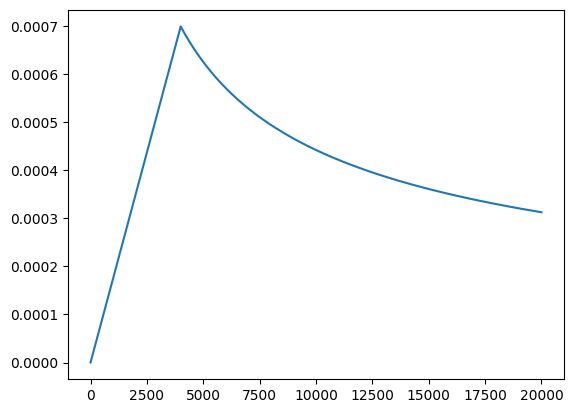

In [144]:
plt.plot([learning_rate(i, D_MODEL, 1.0, WARMUP_STEPS)
         for i in range(0, 20000)])

## Formatting the Data
We use `Dataset` and `DataLoader`. `Dataset` implements two methods: `__init__`, `__len__` and `__getitem__`. The last method returns an item of the dataset given an index. Using `collate_fn`, `DataLoader` returns a batch of `batch_size` samples.

In [145]:
from torch.utils.data import Dataset, DataLoader

In [146]:
class PairDataset(Dataset): # databridge mellan textfiler och Transformer. klassen används för att lagra och hämta par av sekvenser — t.ex. meningar på två språk:

# src_seqs = källspråket (t.ex. engelska)

# tgt_seqs = målspråket (t.ex. svenska)

# Den förvandlar dessa listor till tensorer som modellen kan förstå.
    def __init__(self, src_seqs, tgt_seqs,
                 token2idx):
        self.src_seqs = src_seqs
        self.tgt_seqs = tgt_seqs
        self.token2idx = token2idx

    def __len__(self):
        return len(self.src_seqs)

    def __getitem__(self, idx):
        src_batch = seqs2tensors([self.src_seqs[idx]],
                                 self.token2idx)
        tgt_batch = seqs2tensors([self.tgt_seqs[idx]],
                                 self.token2idx)

        return src_batch[0], tgt_batch[0]

    def collate(self, batch): # Slår ihop meningar och deras padding till en batch /padding är att man fyller på så att den har samma längd vektorerna
        src_batch, tgt_batch = list(zip(*batch))
        src_batch = pad_sequence(src_batch, batch_first=True,
                                 padding_value=0)
        tgt_batch = pad_sequence(tgt_batch, batch_first=True,
                                 padding_value=0)

        return src_batch, tgt_batch

In [147]:
train_dataset = PairDataset(train_src_seqs, train_tgt_seqs,
                            token2idx)
train_dataloader = DataLoader(train_dataset, batch_size=32,
                              shuffle=True,
                              collate_fn=train_dataset.collate)

In [148]:
val_dataset = PairDataset(val_src_seqs, val_tgt_seqs, token2idx)
val_dataloader = DataLoader(
    val_dataset, batch_size=32, collate_fn=val_dataset.collate)

## Training Loop

In [149]:
src_batch

tensor([[ 2, 45, 65,  ...,  0,  0,  0],
        [ 2, 78, 68,  ...,  0,  0,  0],
        [ 2, 36, 51,  ...,  0,  0,  0],
        ...,
        [ 2, 35, 51,  ...,  0,  0,  0],
        [ 2, 35, 51,  ...,  0,  0,  0],
        [ 2, 35, 51,  ...,  0,  0,  0]])

In [150]:
src_batch[:, 1:]

tensor([[45, 65, 63,  ...,  0,  0,  0],
        [78, 68,  4,  ...,  0,  0,  0],
        [36, 51, 64,  ...,  0,  0,  0],
        ...,
        [35, 51, 57,  ...,  0,  0,  0],
        [35, 51, 57,  ...,  0,  0,  0],
        [35, 51, 57,  ...,  0,  0,  0]])

In [151]:
translator = translator.to(DEVICE)

In [152]:
def evaluate(model, loss_fn, dataloader):
    model.eval()
    with torch.no_grad(): # Inaktiverar beräkning av gradienter (dvs. ingen backpropagation). Sparar både minne och beräkningstid eftersom vi inte behöver träna — bara räkna ut resultatet.

        t_loss = 0
        t_correct, t_chars = 0, 0
        for src_batch, tgt_batch in dataloader: # Hämtar batchar (källsekvenser och målspråksekvenser)
            src_batch = src_batch.to(DEVICE)
            tgt_batch = tgt_batch.to(DEVICE)
            tgt_input = tgt_batch[:, :-1]
            tgt_output = tgt_batch[:, 1:]
            src_padding_mask = (src_batch == 0)
            tgt_padding_mask = (tgt_input == 0).float() # Dessa två padding_mask lines betyder att modellen ignorerar paddingen eftersom den egentligen inte behövs
            tgt_output_pred = model(src_batch, tgt_input,
                                    src_padding_mask,
                                    tgt_padding_mask) # får ut modellens förutsägelser
            loss = loss_fn(
                tgt_output_pred.reshape(
                    -1,
                    tgt_output_pred.size(dim=-1)),
                tgt_output.reshape(-1)) # Beräknar loss
            n_chars = (tgt_output != 0).sum() # Räknar hur många riktiga token (inte padding) som finns i batchen.
            t_chars += n_chars
            t_loss += loss.item() * n_chars
            char_pred = torch.argmax(tgt_output_pred, dim=-1)
            char_correct = torch.mul((char_pred == tgt_output),
                                     (tgt_output != 0)).sum()
            # torch.argmax() väljer den mest sannolika token modellen tror på.
            # Sedan jämför vi med den riktiga (tgt_output).
            # Multiplikationen med (tgt_output != 0) ser till att vi inte räknar padding.
            # Det ger oss hur många token modellen gissade rätt.
            t_correct += char_correct.item()
        
        return t_loss / t_chars, t_correct / t_chars

In [153]:
evaluate(translator, loss_fn, val_dataloader)

(tensor(7.2004), tensor(0.0170))

In [154]:
def train(model, loss_fn, optimizer, dataloader):
    model.train()
    t_loss = 0
    t_correct, t_chars = 0, 0
    for src_batch, tgt_batch in tqdm(dataloader):
        src_batch = src_batch.to(DEVICE)
        tgt_batch = tgt_batch.to(DEVICE)
        tgt_input = tgt_batch[:, :-1] # Input som inmatning
        tgt_output = tgt_batch[:, 1:] # Facit
        src_padding_mask = (src_batch == 0).to(DEVICE)
        tgt_padding_mask = (tgt_input == 0).float().to(DEVICE)
        tgt_output_pred = model(src_batch, tgt_input,
                                src_padding_mask,
                                tgt_padding_mask)
        optimizer.zero_grad() # Som förra labben
        loss = loss_fn(
            tgt_output_pred.reshape(
                -1,
                tgt_output_pred.size(dim=-1)),
            tgt_output.reshape(-1))
        loss.backward()
        optimizer.step()
        lr_scheduler.step() # Uppdaterar learning rate
        with torch.no_grad():
            n_chars = (tgt_output != 0).sum()
            t_chars += n_chars
            t_loss += loss.item() * n_chars
            char_pred = torch.argmax(tgt_output_pred, dim=-1)
            char_correct = torch.mul((char_pred == tgt_output),
                                     (tgt_output != 0)).sum()
            t_correct += char_correct.item()

    return t_loss / t_chars, t_correct / t_chars

In [155]:
# translator = torch.compile(translator)

About the loss. Overall, it should computed by individual prediction and divided by the number of chars. By default the crossentropy loss uses the mean. Then we use the mean of the mean. The trend is correct, but the values are not exact. A possible improvement would be to sum and pass through the mask.

In [156]:
EPOCHS = 80
history = {}
history['accuracy'] = []
history['loss'] = []
history['val_accuracy'] = []
history['val_loss'] = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(
        translator, loss_fn, optimizer, train_dataloader)
    history['loss'] += [train_loss.item()]
    history['accuracy'] += [train_acc.item()]
    val_loss, val_acc = evaluate(translator, loss_fn, val_dataloader)
    history['val_loss'] += [val_loss.item()]
    history['val_accuracy'] += [val_acc.item()]
    print((f"Epoch: {epoch}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}, Train acc.: {train_acc:.3f}, Val acc.: {val_acc:.3f}"))

100%|██████████| 500/500 [16:37<00:00,  2.00s/it]


Epoch: 0, Train loss: 3.238, Val loss: 2.432, Train acc.: 0.244, Val acc.: 0.429


100%|██████████| 500/500 [17:50<00:00,  2.14s/it]


Epoch: 1, Train loss: 2.364, Val loss: 2.129, Train acc.: 0.451, Val acc.: 0.527


100%|██████████| 500/500 [18:41<00:00,  2.24s/it]


Epoch: 2, Train loss: 2.137, Val loss: 1.966, Train acc.: 0.527, Val acc.: 0.588


100%|██████████| 500/500 [16:37<00:00,  2.00s/it]


Epoch: 3, Train loss: 1.995, Val loss: 1.882, Train acc.: 0.574, Val acc.: 0.616


 57%|█████▋    | 285/500 [07:23<05:34,  1.56s/it]


KeyboardInterrupt: 

## Plotting the Loss

In [ ]:
epochs = range(EPOCHS)

In [ ]:
history

{'accuracy': [0.07058034837245941,
  0.12049894779920578,
  0.14554204046726227,
  0.2362813651561737,
  0.299296110868454,
  0.3266136646270752,
  0.3435404896736145,
  0.36180806159973145,
  0.37665197253227234,
  0.3930760324001312,
  0.4025809168815613,
  0.4172572195529938,
  0.4278634190559387,
  0.4371289014816284,
  0.45585137605667114,
  0.4621959328651428,
  0.47613003849983215,
  0.48601800203323364,
  0.4966481328010559,
  0.5092654824256897,
  0.5155142545700073,
  0.5240375399589539,
  0.5399827361106873,
  0.5489848852157593,
  0.5583460927009583,
  0.566629946231842,
  0.5766376256942749,
  0.5837722420692444,
  0.59294193983078,
  0.6059184074401855,
  0.6148008108139038,
  0.6239944100379944,
  0.6355583071708679,
  0.6388622522354126,
  0.6524372696876526,
  0.6623491644859314,
  0.6723328828811646,
  0.6799463629722595,
  0.6860275864601135,
  0.6937367916107178,
  0.7054204344749451,
  0.7105918526649475,
  0.7195939421653748,
  0.7258188128471375,
  0.734389960765

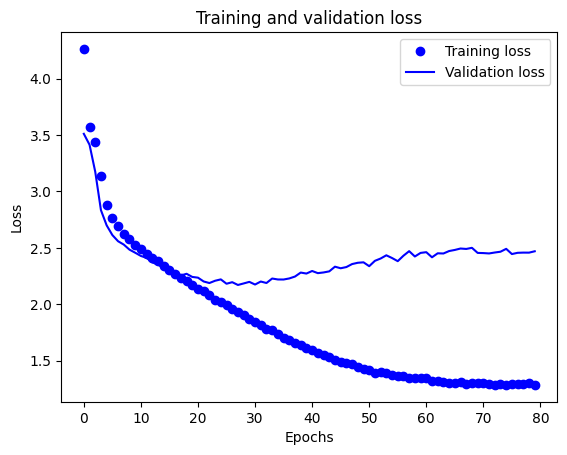

In [ ]:
plt.plot(epochs, history['loss'], 'bo', label='Training loss')
plt.plot(epochs, history['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

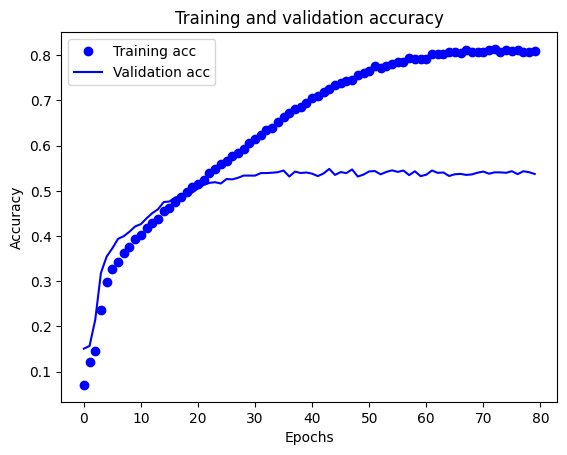

In [ ]:
plt.plot(epochs, history['accuracy'], 'bo', label='Training acc')
plt.plot(epochs, history['val_accuracy'], 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Application

In [ ]:
def greedy_decode(model, src_seq, max_len): # generera text/översätta utan att vi längre har ett facit.
    src_embs = model.embedding(src_seq) # Gör om våra meningar till embeddings
    memory = model.transformer.encoder(src_embs) # Slänger in de i encodern
    tgt_seq = torch.LongTensor([token2idx['<s>']]).to(DEVICE) # Decodern påbörjas, börjar så klart på <s> eftersom meningen börjas
    tgt_embs = model.embedding(tgt_seq)
    max_len = min(max_len, MAX_LEN) # Säkerställer att den inte går över gränsen för max längden

    for _ in range(max_len-1):
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_embs.size(dim=0), device=device) # En mask för att decodern inte kan se framtida tokens, bara förgående
        tgt_output = model.transformer.decoder(tgt_embs,
                                               memory,
                                               tgt_mask=tgt_mask) # Decodern tar all data det får tillgång till och börjar spotta ut
        char_prob = model.fc(tgt_output[-1]) # Omvandlar till sannolikheter
        next_char = torch.argmax(char_prob) # Tar den mest sannolika ordet och gör om det till en vektor
        tgt_seq = torch.cat(
            (tgt_seq,
             torch.unsqueeze(next_char, dim=0)), dim=0)
        tgt_embs = model.embedding(tgt_seq) # Uppdaterar decodern inför nästa steg
        if next_char.item() == token2idx['</s>']:  # När vi når slutmeningen är vi klara
            break 
    return tgt_seq[1:]

`greedy_decode` with a batched input: `greedy_decode_batched`

In [ ]:
def greedy_decode_batched(model, src_seq, max_len): # Samma som ovan men den gör det för en batch istället, (flera meningar)
    src_seq = src_seq.unsqueeze(0) if src_seq.dim() == 1 else src_seq
    src_embs = model.embedding(src_seq)
    memory = model.transformer.encoder(src_embs)
    tgt_seq = torch.LongTensor([[token2idx['<s>']]]).to(DEVICE)
    tgt_embs = model.embedding(tgt_seq)
    max_len = min(max_len, MAX_LEN)

    for _ in range(max_len - 1):
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_embs.size(dim=1), device=device)
        tgt_output = model.transformer.decoder(
            tgt_embs, memory, tgt_mask=tgt_mask)
        char_prob = model.fc(tgt_output[:, -1, :])  
        next_char = torch.argmax(char_prob, dim=-1).unsqueeze(-1)
        tgt_seq = torch.cat((tgt_seq, next_char), dim=1)
        tgt_embs = model.embedding(tgt_seq)
        if next_char.item() == token2idx['</s>']:
            break
    return tgt_seq[0, 1:]

In [ ]:
def translate(model, src_sentence, batched=True): # Här blir våran translate model där vi använder alla algoritmer för att skapa vår translate
    model.eval()
    src = seqs2tensors([src_sentence.strip()], token2idx)[0].to(DEVICE)
    num_chars = src.size(dim=0)
    if batched:
        tgt_chars = greedy_decode_batched(
            model, src, max_len=num_chars + 20)
    else:
        tgt_chars = greedy_decode(
            model, src, max_len=num_chars + 20)
    tgt_chars = tensors2seqs([tgt_chars], idx2token)[0]
    if tgt_chars[-1] == '</s>':
        tgt_chars = tgt_chars[:-1]
    tgt_str = ''.join(tgt_chars)
    return tgt_str

In [ ]:
tgt_sent = translate(translator, "Kom och ät", batched=False)
tgt_sent

'She company.'

In [ ]:
tgt_sent = translate(
    translator, "Idag är det fint väder. Jag ska gå och bada på stranden.", batched=False)
tgt_sent

"It's almost imposssible."

In [ ]:
tgt_sent = translate(translator, "Redkalösköldsfklöte !", batched=False)
tgt_sent

'It all working a bag conale day.'

## Save model

In [ ]:
torch.save(translator.state_dict(), MODEL_NAME)

In [ ]:
with open('pico_translator.vocab', 'w') as f:
    json.dump(token2idx, f)

## Evaluate the Model

In [ ]:
model = Translator(d_model=D_MODEL,
                   nhead=NHEAD,
                   num_decoder_layers=NUM_ENCODER_LAYERS,
                   num_encoder_layers=NUM_DECODER_LAYERS,
                   dim_feedforward=DIM_FF,
                   vocab_size=VOCAB_SIZE,
                   max_len=MAX_LEN)

In [ ]:
model.load_state_dict(torch.load(MODEL_NAME))

<All keys matched successfully>

In [ ]:
model.eval()

Translator(
  (embedding): Embedding(
    (input_embedding): Embedding(79, 512, padding_idx=0)
    (pos_embedding): Embedding(102, 512)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((512,), eps=1e-05, elementwise

In [ ]:
model.state_dict()

OrderedDict([('embedding.input_embedding.weight',
              tensor([[ 0.0280, -0.0047, -0.0184,  ..., -0.0062,  0.0059, -0.0142],
                      [ 0.0336,  0.0012, -0.0139,  ..., -0.0038,  0.0106, -0.0100],
                      [-0.0369, -0.0114, -0.0189,  ..., -0.0078,  0.0602, -0.0282],
                      ...,
                      [ 0.0486,  0.0071, -0.0045,  ..., -0.0130,  0.0138, -0.0209],
                      [ 0.0239,  0.0358, -0.0109,  ..., -0.0113, -0.0435, -0.0921],
                      [ 0.0333, -0.0009, -0.0126,  ..., -0.0054,  0.0152, -0.0101]])),
             ('embedding.pos_embedding.weight',
              tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
                        0.0000e+00,  1.0000e+00],
                      [ 8.4147e-01,  5.4030e-01,  8.2186e-01,  ...,  1.0000e+00,
                        1.0366e-04,  1.0000e+00],
                      [ 9.0930e-01, -4.1615e-01,  9.3641e-01,  ...,  1.0000e+00,
                        2

In [ ]:
model = model.to(DEVICE)

In [ ]:
translate(model, "Jag simmar")

'I sssaw your sish.'

In [ ]:
cand = []
for i, seq in tqdm(enumerate(val_src_seqs)):
    cand.append(translate(model, seq.strip()))
# cand

400it [02:44,  2.43it/s]


In [ ]:
bleu_score(cand, val_tgt_seqs)

tensor(0.0236)